In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

In [155]:
iris = load_iris()

In [156]:
x = iris.data[:, 2:4] # only two columns need for plot decision boundary
y = iris.target

In [157]:
std = StandardScaler()

In [158]:
x = std.fit_transform(x)

In [159]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [160]:
# x_train = std.fit_transform(x_train)
# x_test = std.transform(x_test)

In [161]:
model = SVC(kernel="rbf")

In [162]:
model.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [163]:
model.score(x_train, y_train)

0.95

In [164]:
model.score(x_test, y_test)

1.0

In [165]:
prediction = model.predict(x_test)

In [166]:
accuracy_score(prediction, y_test)

1.0

In [167]:
zero_one_colourmap = ListedColormap(['blue', 'red'])
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)): # 0 0, 1 1
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\ABDULLAH AL MASUM\AppData\Local\Temp\ipykernel_6488\3771811102.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


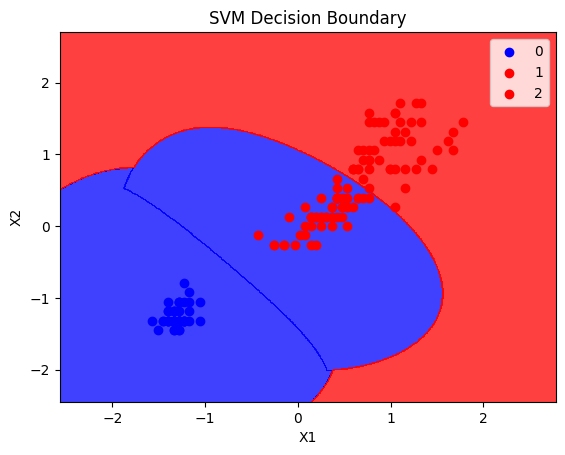

In [168]:
plot_decision_boundary(x, y, model)

Make Circle

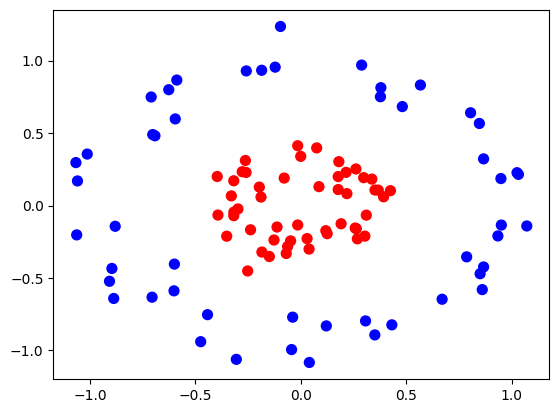

In [169]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
X, y = make_circles(100, factor=.3, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')# c= target columns, s=selected sample

In [170]:
x_train,x_test , y_train, y_test = train_test_split(X, y, test_size=.1, random_state=42)

# Linear Kernel

In [171]:
model1 = SVC(kernel="linear")
model1.fit(x_train, y_train)
model1.score(x_train, y_train)

0.5111111111111111

In [172]:
model1.score(x_test, y_test)

0.4

C:\Users\ABDULLAH AL MASUM\AppData\Local\Temp\ipykernel_6488\3771811102.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


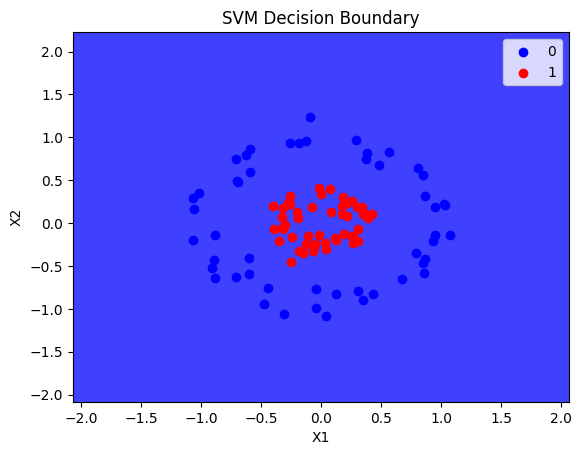

In [173]:
plot_decision_boundary(X, y, model1)

# 3D plot



In [174]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

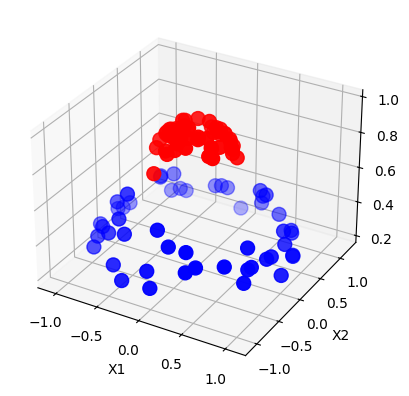

In [175]:
plot_3d_plot(X, y)

# rbf kernel

In [176]:
model2 = SVC(kernel="rbf")
model2.fit(x_train, y_train)
model2.score(x_test, y_test)

1.0

C:\Users\ABDULLAH AL MASUM\AppData\Local\Temp\ipykernel_6488\3771811102.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


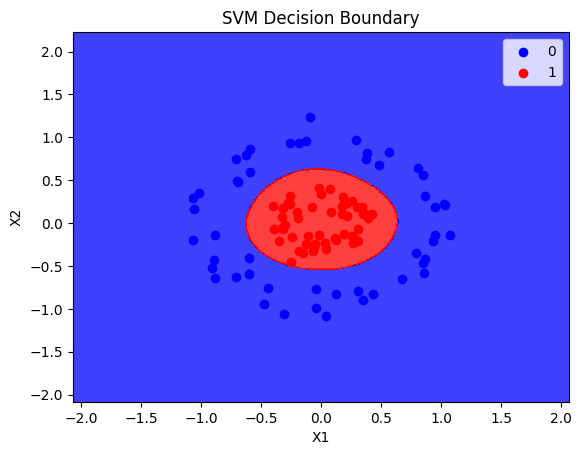

In [177]:
plot_decision_boundary(X, y, model2)

# polynomial kernel

In [180]:
model3 = SVC(kernel='poly', degree=2)
model3.fit(x_train, y_train)
model3.score(x_test, y_test)

1.0

C:\Users\ABDULLAH AL MASUM\AppData\Local\Temp\ipykernel_6488\3771811102.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


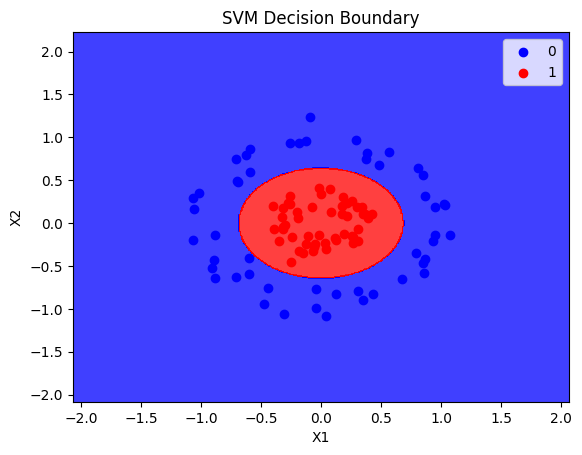

In [181]:
plot_decision_boundary(X, y, model3)

# sigmoid kernel

In [182]:
model4 = SVC(kernel='sigmoid')
model4.fit(x_train, y_train)
model4.score(x_test, y_test)

0.5

C:\Users\ABDULLAH AL MASUM\AppData\Local\Temp\ipykernel_6488\3771811102.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


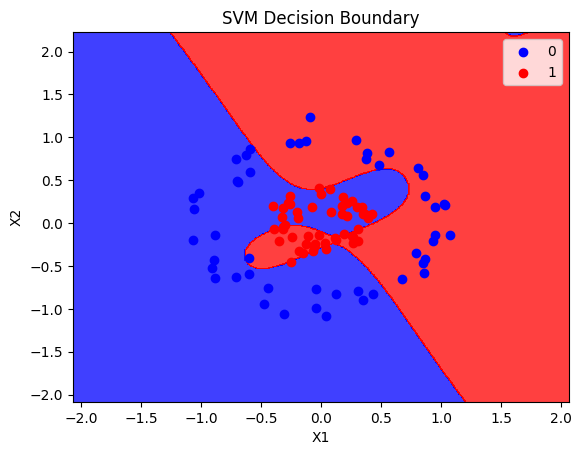

In [183]:
plot_decision_boundary(X, y, model4)